# 01 — Exploratory Data Analysis for Forward Prediction

## Goal

This notebook presents a concise exploratory analysis of the Boom Challenge forward prediction dataset.

The objective is to understand:

- the input and target distributions;
- the presence of physical regimes;
- the main relationships between inputs and outputs;
- the first evidence supporting physics-informed feature engineering and target-specific modeling.

This EDA is intentionally simple and focused. It keeps only the plots and tables that support the modeling strategy used later in the project.

## 1. Imports and Paths

In [17]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FORWARD_DIR = PROJECT_ROOT / "data" / "raw" / "forward_prediction"
INVERSE_DIR = PROJECT_ROOT / "data" / "raw" / "inverse_design"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Forward data directory:", FORWARD_DIR)

Project root: /home/alouiyaz/projects/boom-challenge-ejecta-prediction
Forward data directory: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/forward_prediction


## 2. Load Data

The forward prediction task uses input impact parameters and target ejecta outcomes.

In [18]:
input_cols = [
    "energy", "angle_rad", "coupling", "strength",
    "porosity", "gravity", "atmosphere", "shape_factor",
]

target_cols = [
    "P80", "fines_frac", "oversize_frac",
    "R95", "R50_fines", "R50_oversize",
]

train = pd.read_csv(FORWARD_DIR / "train.csv")
labels = pd.read_csv(FORWARD_DIR / "train_labels.csv")
test = pd.read_csv(FORWARD_DIR / "test.csv")

X = train[input_cols].copy()
y = labels[target_cols].copy()
df = pd.concat([X, y], axis=1)

print("Train inputs:", X.shape)
print("Train targets:", y.shape)
print("Test inputs:", test[input_cols].shape)

display(X.head())
display(y.head())

Train inputs: (2930, 8)
Train targets: (2930, 6)
Test inputs: (492, 8)


,energy,angle_rad,coupling,strength,porosity,gravity,atmosphere,shape_factor
0,3.826405,0.818303,0.861258,1.305809,0.337215,3.71,0.781263,0.784028
1,2.828754,1.193036,0.561245,3.494501,0.058029,1.62,0.136205,0.922737
2,3.068907,0.605872,0.948860,1.366386,0.315632,3.71,0.774704,0.954922
3,2.700574,1.073708,0.713705,3.599419,0.033062,1.62,0.144204,0.932911
4,3.484022,0.863568,1.237205,1.996742,0.278207,9.81,0.414620,1.260855


,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize
0,76.972350,0.184728,0.016671,198.938699,175.527939,76.235779
1,269.057465,0.000622,0.916734,239.268477,447.157838,141.894047
2,104.070923,0.070343,0.094438,192.986417,189.286407,84.235774
3,257.618403,0.001026,0.880122,289.289693,500.000028,169.866473
4,111.717167,0.058576,0.136166,94.229304,97.614864,42.928393


## 3. Data Dictionary

This section summarizes the variables used in the analysis.

In [19]:
data_dictionary = pd.DataFrame([
    ["energy", "Input", "Impact energy proxy."],
    ["angle_rad", "Input", "Impact angle in radians."],
    ["coupling", "Input", "Fraction or efficiency of energy transferred to the surface."],
    ["strength", "Input", "Material strength proxy."],
    ["porosity", "Input", "Material porosity."],
    ["gravity", "Input", "Local gravitational acceleration proxy."],
    ["atmosphere", "Input", "Atmospheric density or resistance proxy."],
    ["shape_factor", "Input", "Shape-related drag or geometry proxy."],
    ["P80", "Target", "Particle size threshold where 80% of ejecta mass is below this size."],
    ["fines_frac", "Target", "Fraction of fine particles."],
    ["oversize_frac", "Target", "Fraction of oversized particles."],
    ["R95", "Target", "Radius containing 95% of ejecta."],
    ["R50_fines", "Target", "Median travel distance of fine particles."],
    ["R50_oversize", "Target", "Median travel distance of oversized particles."],
], columns=["variable", "type", "description"])

display(data_dictionary)

,variable,type,description
0,energy,Input,Impact energy proxy.
1,angle_rad,Input,Impact angle in radians.
2,coupling,Input,Fraction or efficiency of energy transferred t...
3,strength,Input,Material strength proxy.
4,porosity,Input,Material porosity.
5,gravity,Input,Local gravitational acceleration proxy.
6,atmosphere,Input,Atmospheric density or resistance proxy.
7,shape_factor,Input,Shape-related drag or geometry proxy.
8,P80,Target,Particle size threshold where 80% of ejecta ma...
9,fines_frac,Target,Fraction of fine particles.


## 4. Basic Quality Checks

Before modeling, we verify missing values, duplicate rows, and basic statistics.

In [20]:
quality_summary = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "missing_rate": df.isna().mean(),
    "n_unique": df.nunique(),
})

display(quality_summary)
print("Duplicate input rows:", int(X.duplicated().sum()))

,missing_values,missing_rate,n_unique
energy,0,0.0,2930
angle_rad,0,0.0,2930
coupling,0,0.0,2930
strength,0,0.0,2930
porosity,0,0.0,2930
gravity,0,0.0,3
atmosphere,0,0.0,2930
shape_factor,0,0.0,2930
P80,0,0.0,2930
fines_frac,0,0.0,2930


Duplicate input rows: 0


In [21]:
display(df[input_cols].describe().T)
display(df[target_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
energy,2930.0,3.301926,0.515693,2.601520,2.916863,3.178629,3.550105,4.596577
angle_rad,2930.0,0.951386,0.255006,0.524044,0.709770,1.061094,1.184804,1.308300
coupling,2930.0,0.779547,0.291783,0.400526,0.580455,0.671931,0.906774,1.599823
strength,2930.0,2.580928,0.883295,0.810376,1.777277,2.948905,3.358840,3.799996
porosity,2930.0,0.164995,0.134106,0.000013,0.038808,0.076117,0.301247,0.349741
gravity,2930.0,4.960819,3.442831,1.620000,1.620000,3.710000,9.810000,9.810000
atmosphere,2930.0,0.363153,0.268377,0.050157,0.121867,0.191589,0.617854,0.849873
shape_factor,2930.0,0.985043,0.139024,0.750093,0.890412,0.948485,1.033366,1.349924


,count,mean,std,min,25%,50%,75%,max
P80,2930.0,171.891639,65.755283,57.265208,105.231804,193.751286,229.132545,326.836650
fines_frac,2930.0,0.043865,0.068604,0.000143,0.001162,0.002956,0.065213,0.463369
oversize_frac,2930.0,0.513737,0.362087,0.002468,0.102342,0.720982,0.847226,0.968150
R95,2930.0,253.260470,238.543070,18.076380,81.540215,163.335046,349.741891,1310.623251
R50_fines,2930.0,310.884622,246.898723,30.601365,86.771923,227.164319,512.720166,1138.786538
R50_oversize,2930.0,126.181143,108.436996,11.068695,36.721097,87.601506,190.104320,716.141659


### Key observation

The dataset does not require missing-value imputation. The main modeling difficulty comes from non-linear relationships, regime-like input distributions, skewed targets, and out-of-distribution test scenarios.

## 5. Input Distributions

The input distributions help identify discrete regimes and non-uniform sampling patterns.

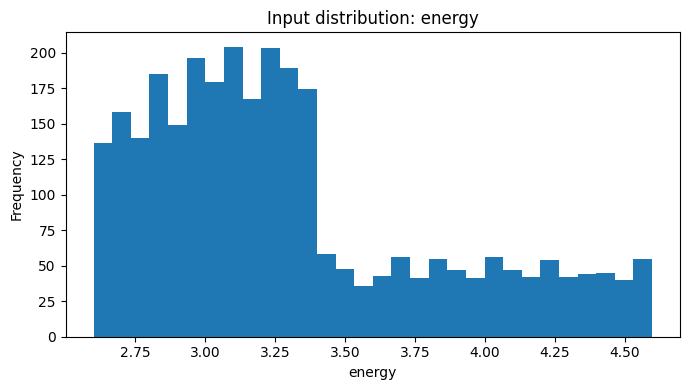

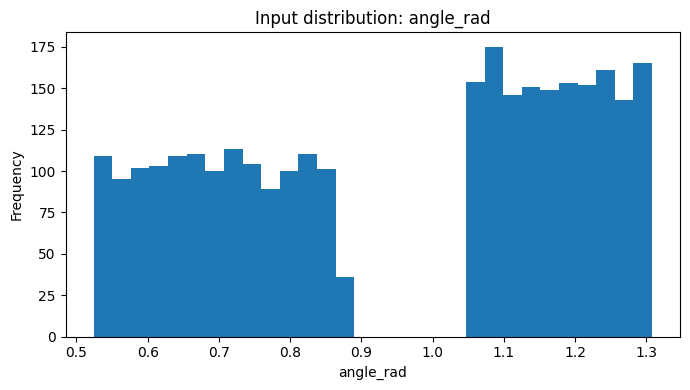

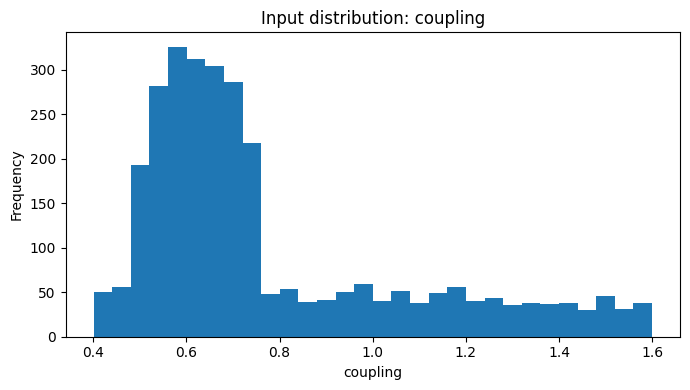

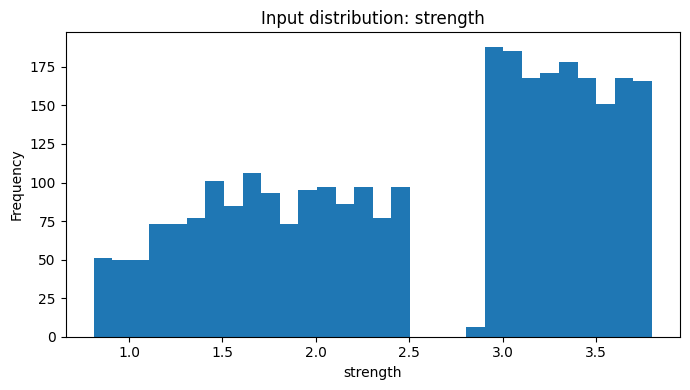

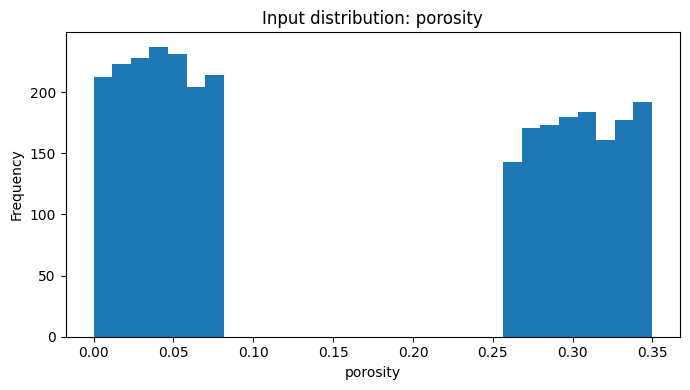

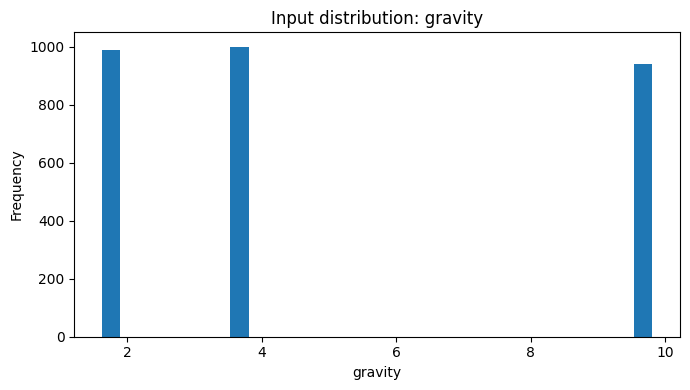

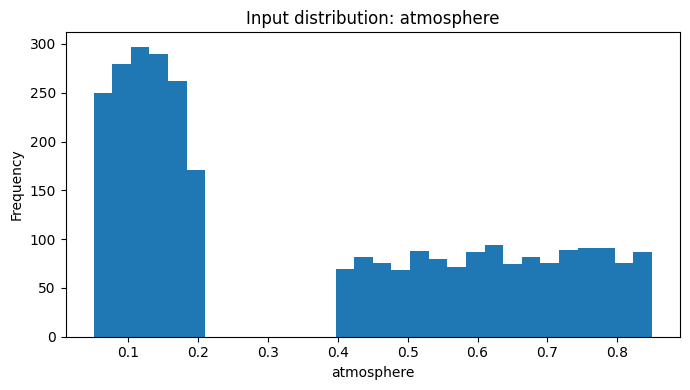

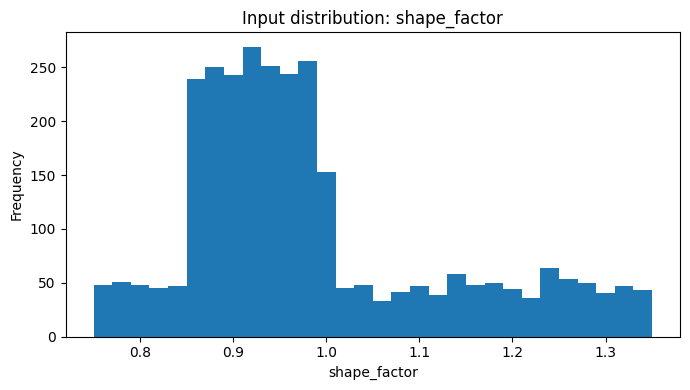

In [22]:
for col in input_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(X[col], bins=30)
    plt.title(f"Input distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### Input distribution notes

Several variables show regime-like behavior rather than fully continuous distributions:

- gravity has a small number of discrete levels;
- porosity, angle_rad, strength, and atmosphere show separated clusters.
- this supports adding regime indicators and using tree-based models.

## 6. Target Distributions

The target distributions show that the six outputs have different statistical behavior.

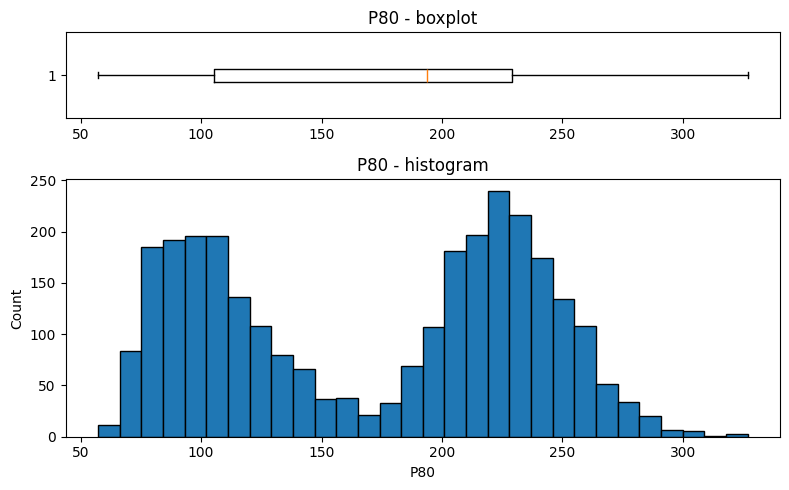

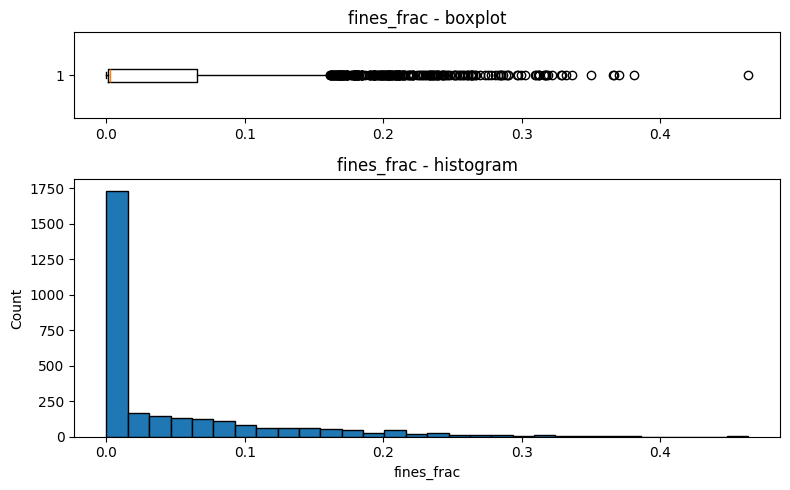

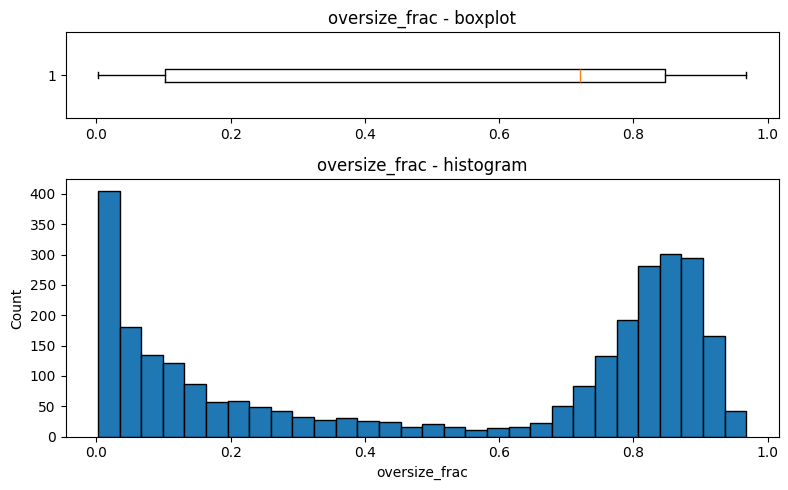

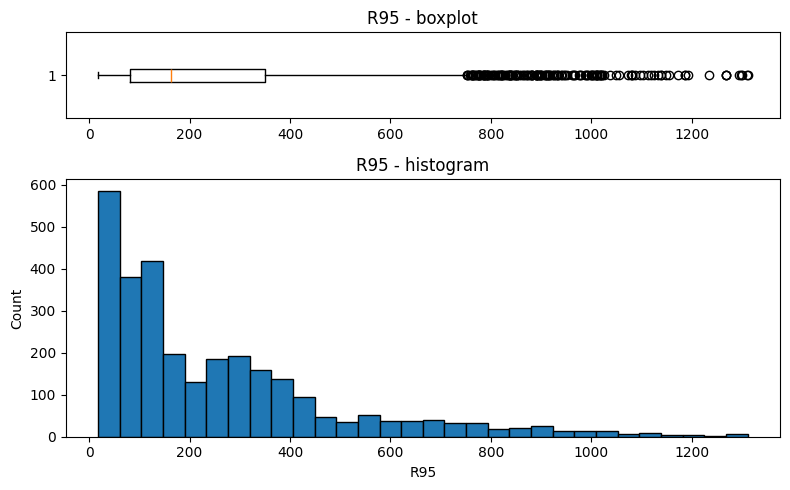

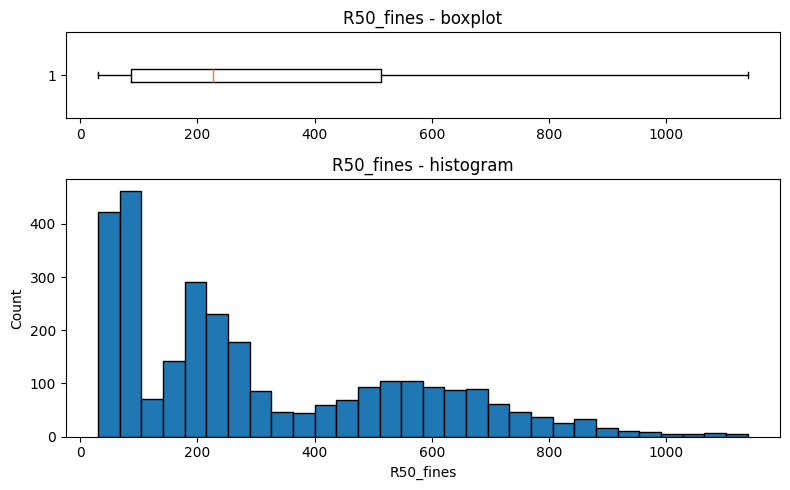

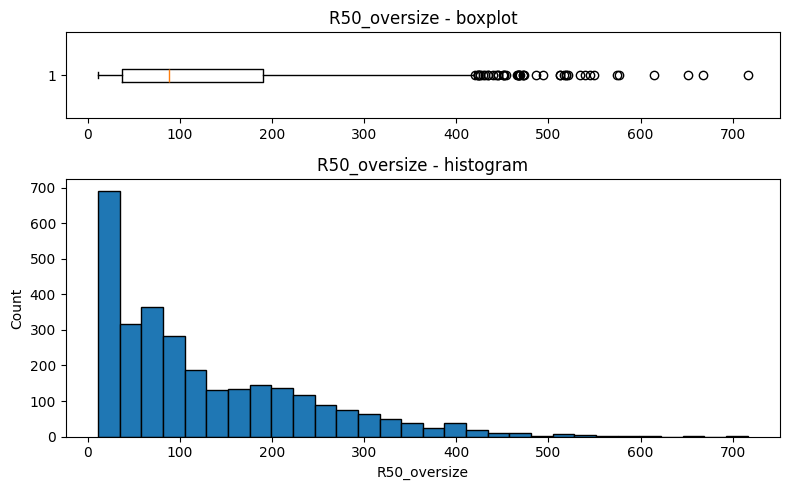

In [25]:

for col in target_cols:
    fig, axes = plt.subplots(
        2, 1,
        figsize=(8, 5),
        gridspec_kw={"height_ratios": [1, 3]}
    )

    # Boxplot
    axes[0].boxplot(y[col].dropna(), vert=False)
    axes[0].set_title(f"{col} - boxplot")
    axes[0].set_xlabel("")

    # Histogram
    axes[1].hist(y[col].dropna(), bins=30, edgecolor="black")
    axes[1].set_title(f"{col} - histogram")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

### Target skewness and outlier analysis

Before modeling, we also quantify the asymmetry and extreme values of each target. This helps identify which targets may require special treatment, such as robust models, clipping, log-transform testing, or target-specific modeling.

In [24]:


def outlier_summary_iqr(df, columns):
    rows = []

    for col in columns:
        s = df[col].dropna()

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = (s < lower_bound) | (s > upper_bound)

        rows.append({
            "target": col,
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
            "min": s.min(),
            "max": s.max(),
            "skewness": skew(s),
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_iqr_bound": lower_bound,
            "upper_iqr_bound": upper_bound,
            "n_outliers_iqr": outliers.sum(),
            "outlier_pct_iqr": 100 * outliers.mean()
        })

    return pd.DataFrame(rows)

target_outlier_summary = outlier_summary_iqr(y, target_cols)
display(target_outlier_summary.sort_values("skewness", ascending=False))

,target,mean,median,std,min,max,skewness,Q1,Q3,IQR,lower_iqr_bound,upper_iqr_bound,n_outliers_iqr,outlier_pct_iqr
1,fines_frac,0.043865,0.002956,0.068604,0.000143,0.463369,1.917308,0.001162,0.065213,0.064051,-0.094915,0.161290,248,8.464164
3,R95,253.260470,163.335046,238.543070,18.076380,1310.623251,1.601580,81.540215,349.741891,268.201676,-320.762299,752.044405,164,5.597270
5,R50_oversize,126.181143,87.601506,108.436996,11.068695,716.141659,1.273554,36.721097,190.104320,153.383223,-193.353738,420.179155,45,1.535836
4,R50_fines,310.884622,227.164319,246.898723,30.601365,1138.786538,0.845247,86.771923,512.720166,425.948243,-552.150441,1151.642530,0,0.000000
0,P80,171.891639,193.751286,65.755283,57.265208,326.836650,-0.089226,105.231804,229.132545,123.900741,-80.619307,414.983656,0,0.000000
2,oversize_frac,0.513737,0.720982,0.362087,0.002468,0.968150,-0.282590,0.102342,0.847226,0.744884,-1.014983,1.964552,0,0.000000


### Target distribution notes

The target distributions are not equally difficult.

The skewness and IQR outlier analysis shows that:

- fines_frac is highly skewed and contains many near-zero values;
- R95 has a long right tail and several upper-tail outliers;
- R50_oversize is also right-skewed, but less extreme than R95;
- R50_fines has a very wide spread, even though IQR does not flag outliers;
- P80 is not strongly skewed, but shows a structured multi-modal distribution;
- oversize_frac shows strong regime behavior rather than a simple Gaussian-like pattern.

This supports a target-specific modeling strategy instead of using one single global model.

### Modeling implications

The skewness and outlier analysis suggests several modeling directions:

- For highly right-skewed targets such as fines_frac and R95, target transformations such as log1p could be tested to reduce the influence of extreme values.
- For distance-related targets, robust metrics such as MAE, RMSE, and P95 absolute error should be monitored because a model can perform well on average while still making large errors on rare long-distance cases.
- For targets with regime-like distributions, such as P80 and oversize_frac, tree-based models may be useful because they can capture threshold effects and interactions between physical regimes.
- Since each target has a different distribution, a target-specific modeling strategy should be considered instead of using one single model configuration for all outputs.

## 7. Correlation Analysis

Pearson correlation captures linear relationships. Spearman correlation captures monotonic relationships and is more robust for non-linear patterns.

In [8]:
pearson_corr = df[input_cols + target_cols].corr(method="pearson").loc[input_cols, target_cols]
spearman_corr = df[input_cols + target_cols].corr(method="spearman").loc[input_cols, target_cols]

display(pearson_corr.round(3))
display(spearman_corr.round(3))

pearson_corr.to_csv(REPORTS_DIR / "eda_input_target_pearson_corr.csv")
spearman_corr.to_csv(REPORTS_DIR / "eda_input_target_spearman_corr.csv")

,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize
energy,-0.638,0.505,-0.632,0.280,0.110,0.199
angle_rad,0.866,-0.617,0.883,-0.358,-0.121,-0.249
coupling,-0.679,0.717,-0.690,0.331,0.124,0.217
strength,0.917,-0.733,0.921,-0.385,-0.130,-0.261
porosity,-0.906,0.645,-0.923,0.369,0.122,0.258
gravity,-0.014,0.018,-0.014,-0.677,-0.804,-0.744
atmosphere,-0.861,0.613,-0.880,0.350,0.114,0.249
shape_factor,-0.408,0.291,-0.417,0.130,0.023,0.095


,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize
energy,-0.614,0.602,-0.612,0.240,0.116,0.175
angle_rad,0.750,-0.748,0.750,-0.290,-0.116,-0.206
coupling,-0.654,0.691,-0.660,0.260,0.131,0.177
strength,0.873,-0.863,0.872,-0.314,-0.128,-0.218
porosity,-0.757,0.758,-0.757,0.288,0.115,0.205
gravity,-0.013,0.014,-0.013,-0.896,-0.942,-0.932
atmosphere,-0.743,0.744,-0.743,0.285,0.110,0.206
shape_factor,-0.295,0.297,-0.295,0.104,0.031,0.079


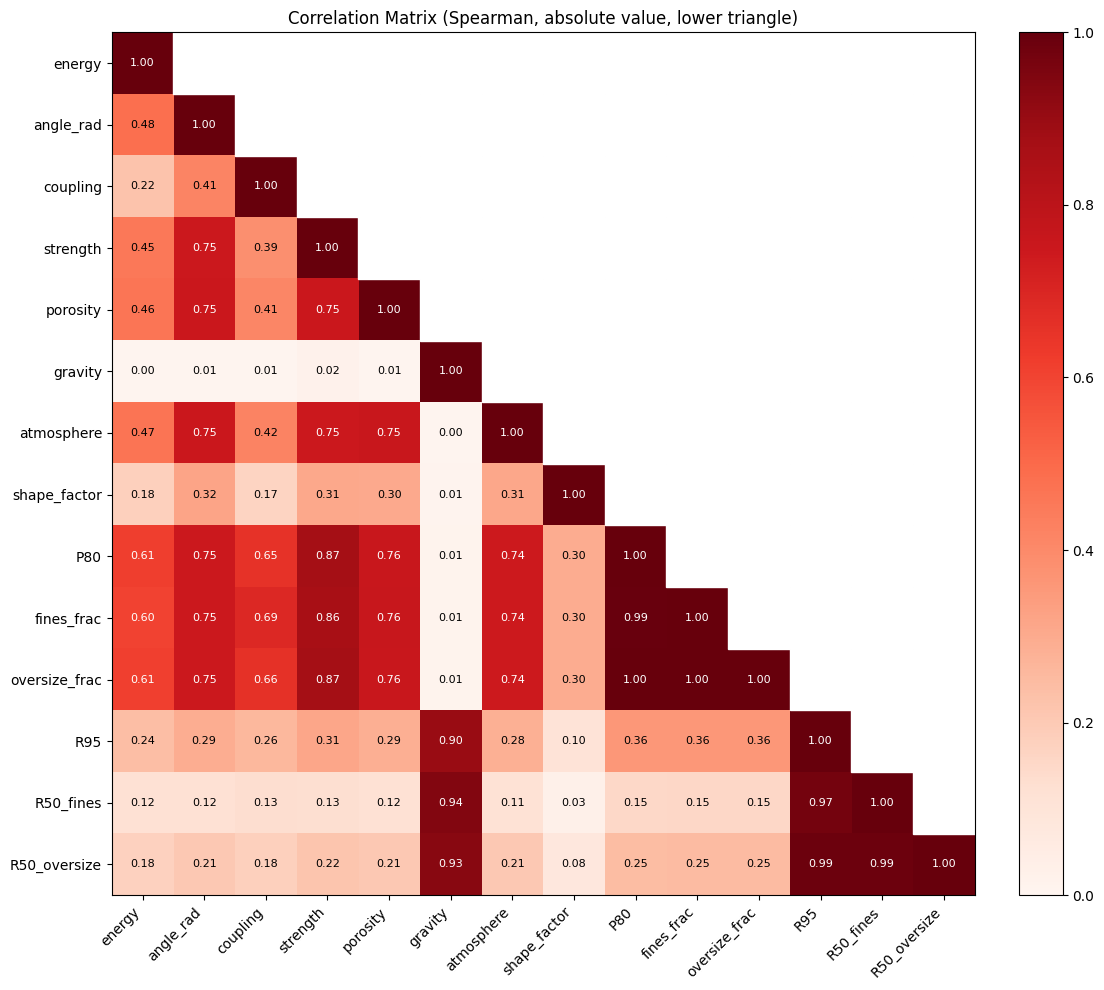

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

all_df = pd.concat([X, y], axis=1)
corr_full = all_df.corr(method="spearman").abs()

mask = np.triu(np.ones_like(corr_full, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_full.values, cmap="Reds", vmin=0, vmax=1)

ax.set_xticks(np.arange(len(corr_full.columns)))
ax.set_yticks(np.arange(len(corr_full.index)))
ax.set_xticklabels(corr_full.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_full.index)

for i in range(corr_full.shape[0]):
    for j in range(corr_full.shape[1]):
        if not mask[i, j]:  # lower triangle + diagonal only
            val = corr_full.iloc[i, j]

            # white text on dark red cells, black text otherwise
            text_color = "white" if val >= 0.60 else "black"

            ax.text(
                j, i, f"{val:.2f}",
                ha="center", va="center",
                fontsize=8,
                color=text_color
            )

# hide upper triangle
for i in range(corr_full.shape[0]):
    for j in range(corr_full.shape[1]):
        if mask[i, j]:
            ax.add_patch(
                plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color="white", ec="white")
            )

ax.set_title("Correlation Matrix (Spearman, absolute value, lower triangle)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Correlation insights

The Spearman correlation matrix highlights several important patterns.

- Fragmentation-related targets such as P80, fines_frac, and oversize_frac are strongly associated with strength, porosity, angle_rad, atmosphere, and coupling.
- Distance-related targets such as R95, R50_fines, and R50_oversize are dominated by gravity, which shows the strongest correlation with these outputs.
- The correlation structure differs across target families, suggesting that fragmentation and distance are driven by partly different mechanisms.
- Strong correlations among some targets also suggest that shared physical processes govern multiple ejecta outcomes.

Overall, the matrix supports a target-specific modeling strategy and motivates the use of physics-informed features and regime-based modeling.

## 8. Bivariate Analysis: Key Input-Target Relationships

This section keeps only the most useful scatter plots for understanding the modeling logic.

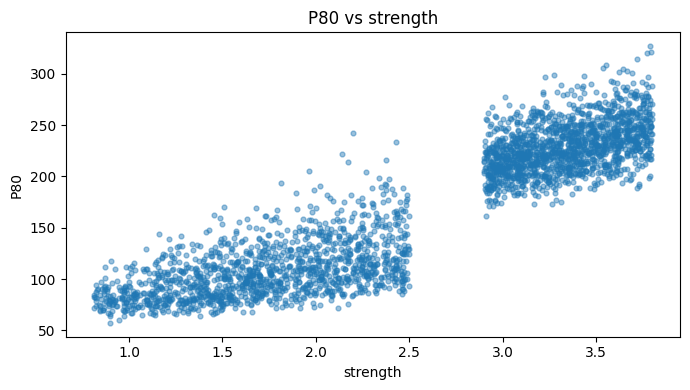

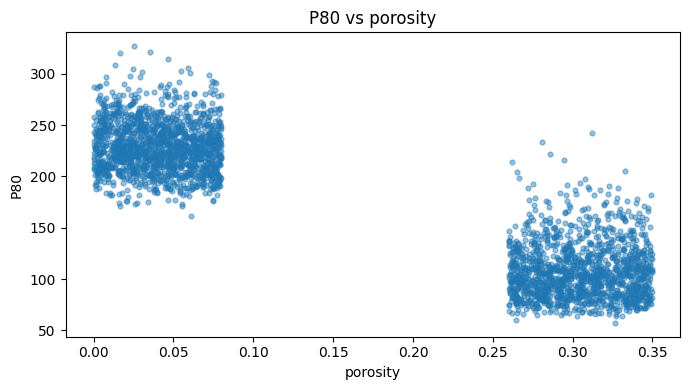

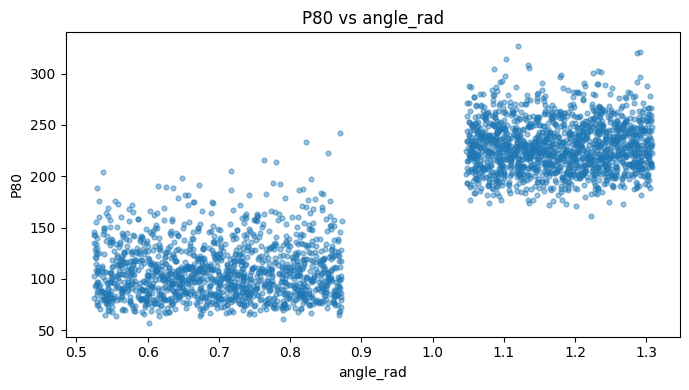

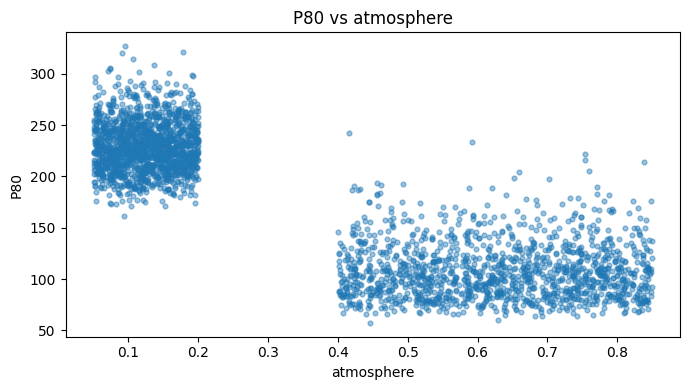

/tmp/ipykernel_6040/2894030344.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_level, labels=levels)


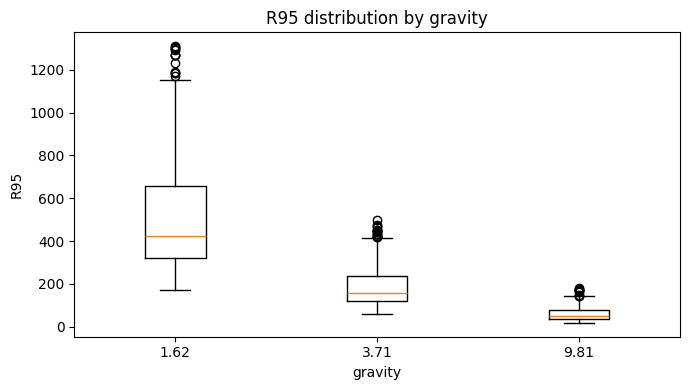

/tmp/ipykernel_6040/2894030344.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_level, labels=levels)


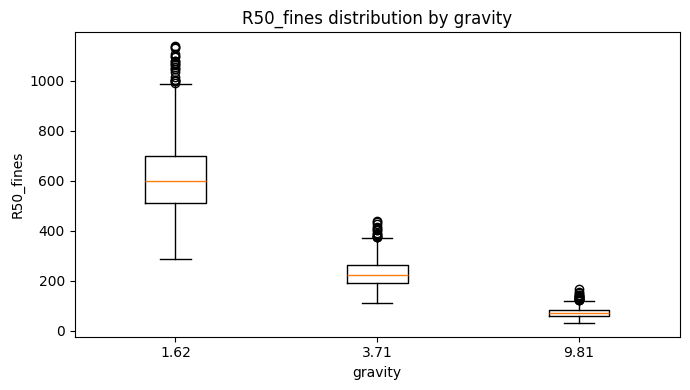

/tmp/ipykernel_6040/2894030344.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_level, labels=levels)


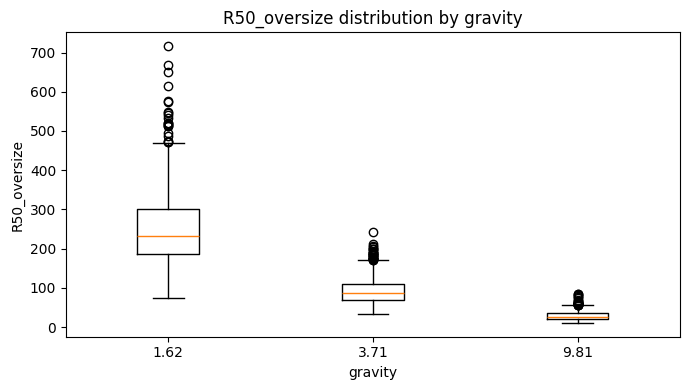

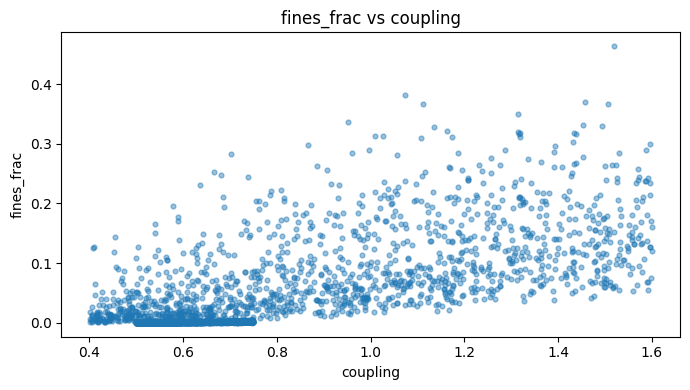

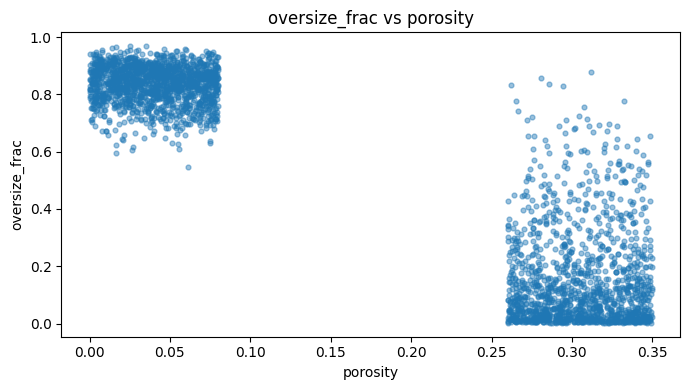

In [29]:
# Important key-pair analysis

key_pairs = [
    ("strength", "P80"),
    ("porosity", "P80"),
    ("angle_rad", "P80"),
    ("atmosphere", "P80"),
    ("gravity", "R95"),
    ("gravity", "R50_fines"),
    ("gravity", "R50_oversize"),
    ("coupling", "fines_frac"),
    ("porosity", "oversize_frac"),
]

for x_col, y_col in key_pairs:
    n_unique = df[x_col].nunique()

    plt.figure(figsize=(7, 4))

    if n_unique <= 10:
        # Boxplot for discrete or regime-like variables
        levels = sorted(df[x_col].dropna().unique())
        data_by_level = [
            df.loc[df[x_col] == level, y_col].dropna()
            for level in levels
        ]

        plt.boxplot(data_by_level, labels=levels)
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.title(f"{y_col} distribution by {x_col}")

    else:
        # Scatter plot for continuous variables
        plt.scatter(df[x_col], df[y_col], s=12, alpha=0.45)
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.title(f"{y_col} vs {x_col}")

    plt.tight_layout()
    plt.show()

### Bivariate analysis takeaways

The bivariate plots show clear physical patterns. Distance targets are strongly driven by gravity: low-gravity scenarios produce larger and more variable ejecta ranges, while high-gravity scenarios produce shorter distances. Fragmentation targets are more related to material and impact properties such as coupling, porosity, strength, angle, and atmosphere.

The plots also reveal regime-like behavior, especially for oversize_frac versus porosity, where the data separates into distinct groups. These observations suggest that the relationships are not purely linear and that interactions between variables are important.

This supports the use of physics-informed features, regime indicators, and target-specific models.

## 09. Multivariate View: Material Regimes

The distributions suggest that porosity and strength define material regimes. We create simple bins to inspect their relationship with fragmentation targets.

In [13]:
analysis_df = df.copy()
analysis_df["porosity_regime"] = np.where(analysis_df["porosity"] > 0.15, "high_porosity", "low_porosity")
analysis_df["strength_regime"] = np.where(analysis_df["strength"] > 2.6, "high_strength", "low_strength")
analysis_df["material_regime"] = analysis_df["porosity_regime"] + "__" + analysis_df["strength_regime"]

material_summary = analysis_df.groupby("material_regime")[["P80", "fines_frac", "oversize_frac"]].agg([
    "count", "mean", "median", "std", "min", "max"
])

display(material_summary)
material_summary.to_csv(REPORTS_DIR / "eda_fragmentation_summary_by_material_regime.csv")

P80                                                            fines_frac                                                    \
                            count        mean      median        std         min         max      count      mean    median       std       min       max   
material_regime                                                                                                                                             
high_porosity__low_strength  1381  107.907518  103.254738  27.397874   57.265208  242.420286       1381  0.091465  0.070738  0.075497  0.000832  0.463369   
low_porosity__high_strength  1549  228.936229  227.009310  24.564020  161.158610  326.836650       1549  0.001428  0.001230  0.000860  0.000143  0.006812   

                            oversize_frac                                                    
                                    count      mean    median       std       min       max  
material_regime                                                                              
high_porosity__low_strength          1381  0.153955  0.091239  0.168772  0.002468  0.876623  
low_porosity__high_strength          1549  0.834498  0.842363  0.065156  0.547829  0.968150

<Figure size 800x400 with 0 Axes>

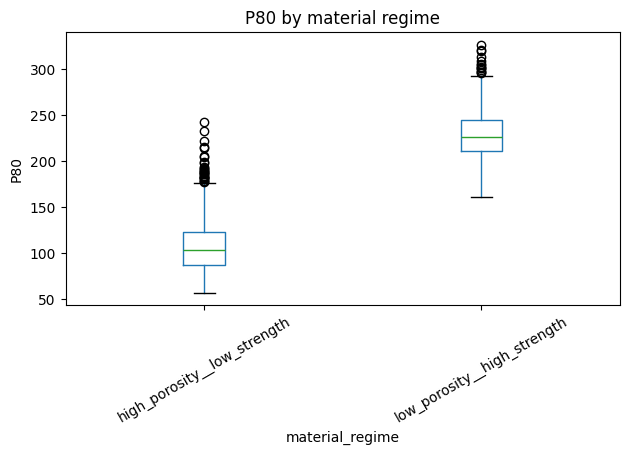

<Figure size 800x400 with 0 Axes>

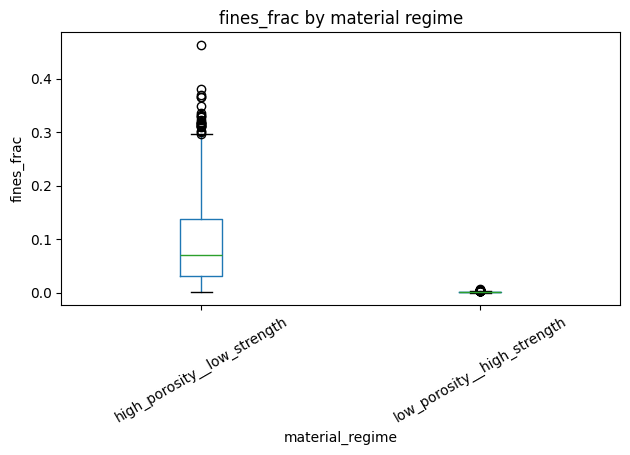

<Figure size 800x400 with 0 Axes>

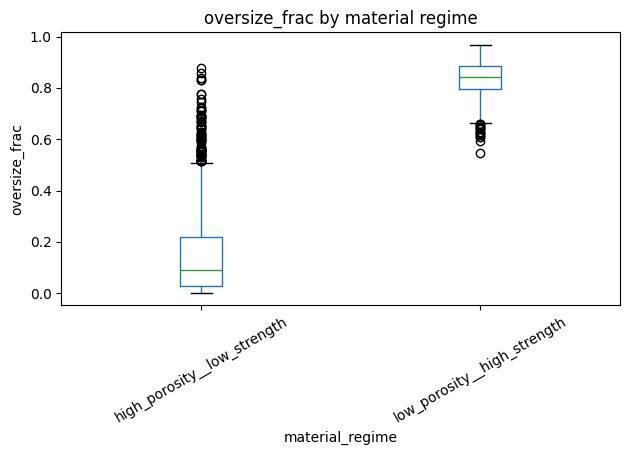

In [14]:
for target in ["P80", "fines_frac", "oversize_frac"]:
    plt.figure(figsize=(8, 4))
    analysis_df.boxplot(column=target, by="material_regime", grid=False, rot=30)
    plt.title(f"{target} by material regime")
    plt.suptitle("")
    plt.xlabel("material_regime")
    plt.ylabel(target)
    plt.tight_layout()
    plt.show()

### Material regime insight

Fragmentation outputs vary clearly across exploratory porosity and strength regimes. This supports adding material-resistance features and simple regime indicators in the modeling pipeline.

## 10. Test Set Shift Check

The test set contains out-of-distribution scenarios. Before modeling, we compare train and test input distributions.

In [15]:
test_X = test[input_cols].copy()

shift_rows = []
for col in input_cols:
    shift_rows.append({
        "feature": col,
        "train_min": X[col].min(),
        "test_min": test_X[col].min(),
        "train_mean": X[col].mean(),
        "test_mean": test_X[col].mean(),
        "train_max": X[col].max(),
        "test_max": test_X[col].max(),
    })

shift_summary = pd.DataFrame(shift_rows)
display(shift_summary)
shift_summary.to_csv(REPORTS_DIR / "eda_train_test_input_shift_summary.csv", index=False)

,feature,train_min,test_min,train_mean,test_mean,train_max,test_max
0,energy,2.601520,3.014554,3.301926,4.113911,4.596577,4.696348
1,angle_rad,0.524044,0.700266,0.951386,0.915256,1.308300,1.213174
2,coupling,0.400526,0.200334,0.779547,0.807955,1.599823,1.691957
3,strength,0.810376,0.900823,2.580928,2.418001,3.799996,4.193536
4,porosity,0.000013,0.080113,0.164995,0.203067,0.349741,0.328892
5,gravity,1.620000,1.020000,4.960819,5.175833,9.810000,10.470000
6,atmosphere,0.050157,0.002391,0.363153,0.596657,0.849873,0.999355
7,shape_factor,0.750093,0.703532,0.985043,1.137319,1.349924,1.495898


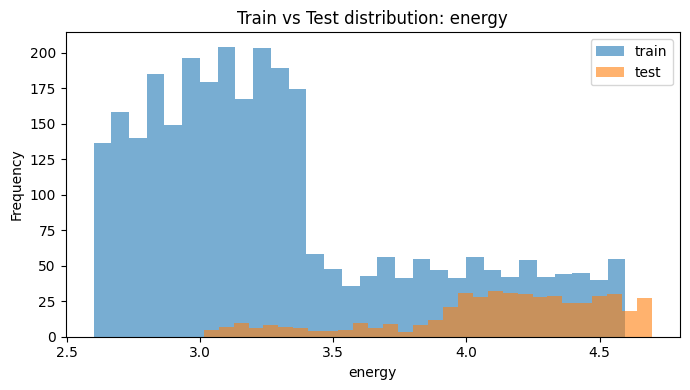

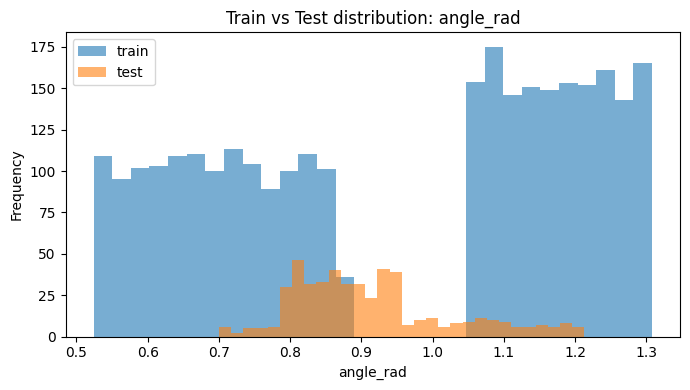

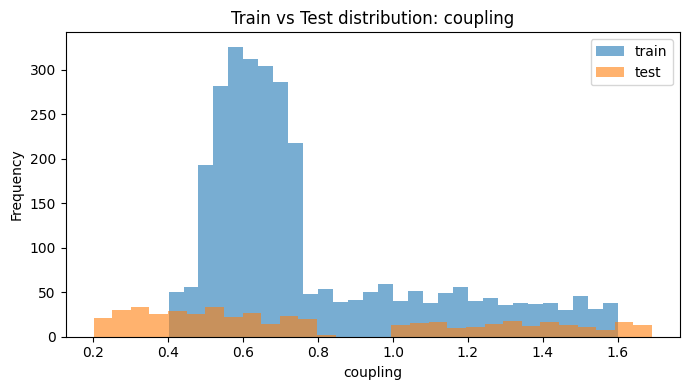

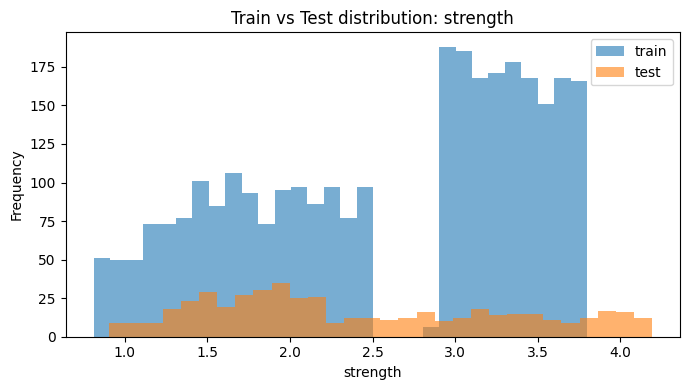

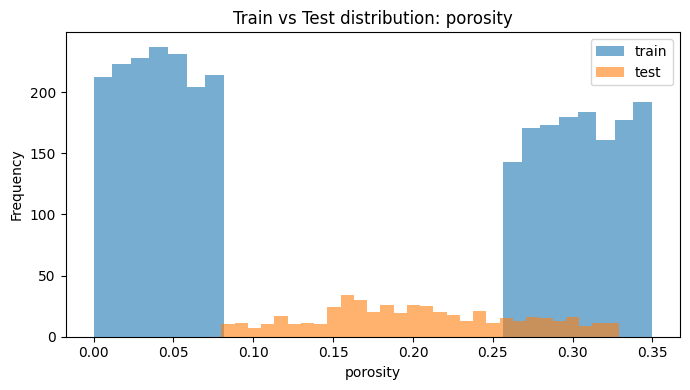

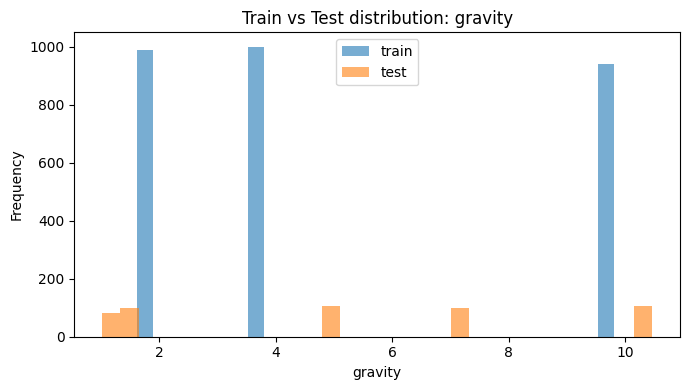

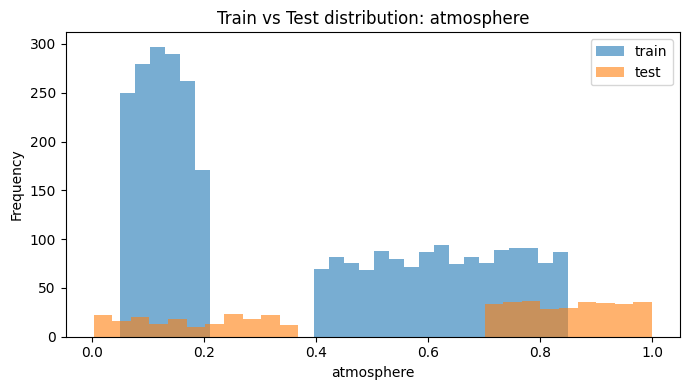

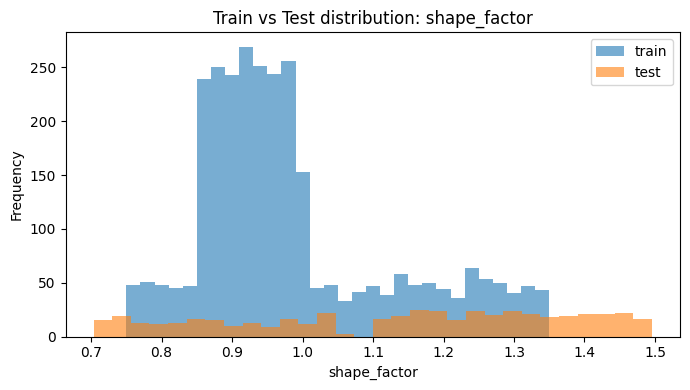

In [16]:
for col in input_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(X[col], bins=30, alpha=0.6, label="train")
    plt.hist(test_X[col], bins=30, alpha=0.6, label="test")
    plt.title(f"Train vs Test distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Train-test shift insight

The test set differs from the training distribution, especially in several physical inputs. This confirms that the final model must be evaluated not only by cross-validation metrics but also by OOD diagnostics and physical plausibility checks.

## 11. EDA Conclusions and Modeling Implications

The EDA supports the following modeling decisions:

1. **Use physics-informed features** rather than only raw inputs.
2. **Use target-specific models**, because fragmentation and distance targets behave differently.
3. **Use tree-based models as strong tabular baselines**, because the relationships are non-linear and regime-dependent.
4. **Treat distance targets carefully**, because they are skewed, gravity-sensitive, and affected by OOD extrapolation.
5. **Add OOD checks before final submission**, because the test set differs from the training distribution.
6. **Use robust inverse design**, because the inverse task requires satisfying hard constraints on P80 and R95.

These conclusions directly motivate the later modeling notebooks.